In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

In [ ]:
#1. Number of rows and columns 
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 5268
Columns: 13


In [5]:
# 2. Display the last 75 rows 
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
5198,04/16/2008,14:23,"Off Annobon Island, Equatorial Guinea",Military - Government of Equatorial Guinea,NaN,Bata - Annobon Island,Antonov An-32B,3C-5GE,1609,13.0,13.0,0.0,Crashed into the ocean after skidding off the ...
5199,04/28/2008,09:38,"Off Crimea, Black Sea",Naftogaz,NaN,NaN,Mil Mi-8T,UR-24275,98734295,20.0,20.0,0.0,The helicopter crashed after the tail section ...
5200,05/02/2008,10:10,"Near Rumbek, Sudan",Southern Sudan Air Connection,NaN,Wau - Rumbek - Juba,Beechcraft 1900C,5Y-FLX,UC-65,24.0,24.0,0.0,The pilot radioed a control tower in the city ...
5201,05/17/2008,16:30,"Stehekin, Washington",Chelan Air Service,NaN,Chelan - Stehekin,de Havilland Canada DHC-2 Mark I Beaver,N5998Q,1151,5.0,2.0,0.0,The float plane flipped and crashed as it atte...
5202,05/23/2008,01:25,"Billings, Montana",Alpine Aviation,5008,Billings - Great Falls,Beechcraft 1900C,N195GA,U-65,1.0,1.0,0.0,"After taking off and being told to turn left,..."


In [6]:
# 4. Is there any missing data
missing = pd.DataFrame({
    'Missing values': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(1)
})
missing

,Missing values,Missing %
Date,0,0.0
Time,2219,42.1
Location,20,0.4
Operator,18,0.3
Flight #,4199,79.7
Route,1707,32.4
Type,27,0.5
Registration,335,6.4
cn/In,1228,23.3
Aboard,22,0.4


*#4. How to treat the missing values*
## Question 4: Treating the missing data

Every column except **Date** has missing data. The method depends on why the data is missing.

**Missing Completely at Random (MCAR)** — no pattern to the gaps, so deleting them doesn't bias anything.

- **Location (20), Operator (18), Type (27), Aboard (22), Fatalities (12)** → **drop the rows**. Under 1% of the data in total, so deleting them changes nothing. There is no way to work out a missing location, airline or aircraft, and inventing fatality figures would fake the result.
- **Ground (22)** → **fill with 0**. 95% of crashes had no ground deaths, so 0 is the median, the mode and almost certainly the true value.

**Missing at Random (MAR)** — the gaps follow a pattern caused by another column (the crash date, or the operator), not by the missing value itself.

- **Time (42%), Route (32%), Summary (7%)** → **fill with "Unknown"**. Too many rows to delete, but nothing sensible to estimate, so label them and exclude these columns from any analysis that needs them complete.
- **Flight # (80%), Registration (6%), cn/In (23%)** → **drop the columns**. Military and private flights never had flight numbers or civil registrations. All three are ID codes with no use in this analysis.

**Missing Not at Random (MNAR)** — no column qualifies, since no value is missing because of what the value is.

In [ ]:
# 5. Create fatality_locations from the RAW data 
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
#6. Date with the highest number of fatalities
worst = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(f"Date: {worst['Date']}")
print(f"Location: {worst['Location']}")
print(f"Aboard: {int(worst['Aboard'])}, Fatalities: {int(worst['Fatalities'])}")


Date: 03/27/1977
Location: Tenerife, Canary Islands
Aboard: 644, Fatalities: 583


In [ ]:
#7. Compare Aboard vs Fatalities
no_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print("Crashes with zero fatalities:", len(no_fatalities))


Crashes with zero fatalities: 58


In [ ]:
#8. Split Location into Region and State/Country
split = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)
has_region = split[1].notna()

fatality_locations['Region'] = split[0].where(has_region).str.strip()
fatality_locations['State/Country'] = split[1].where(has_region, split[0]).str.strip()
fatality_locations = fatality_locations.drop(columns='Location')
fatality_locations = fatality_locations[['Date', 'Region', 'State/Country', 'Aboard', 'Fatalities']]
fatality_locations.head(10)

,Date,Region,State/Country,Aboard,Fatalities
0,09/17/1908,Fort Myer,Virginia,2.0,1.0
1,07/12/1912,AtlantiCity,New Jersey,5.0,5.0
2,08/06/1913,"Victoria, British Columbia",Canada,1.0,1.0
3,09/09/1913,NaN,Over the North Sea,20.0,14.0
4,10/17/1913,Near Johannisthal,Germany,30.0,30.0
5,03/05/1915,Tienen,Belgium,41.0,21.0
6,09/03/1915,Off Cuxhaven,Germany,19.0,19.0
7,07/28/1916,Near Jambol,Bulgeria,20.0,20.0
8,09/24/1916,Billericay,England,22.0,22.0
9,10/01/1916,Potters Bar,England,19.0,19.0


In [15]:
# 9. Order by fatalities (highest to lowest), select first 100
top_100 = (fatality_locations
           .sort_values('Fatalities', ascending=False)
           .head(100)
           .reset_index(drop=True))
top_100

,Date,Region,State/Country,Aboard,Fatalities
0,03/27/1977,Tenerife,Canary Islands,644.0,583.0
1,08/12/1985,"Mt. Osutaka, near Ueno Village",Japan,524.0,520.0
2,11/12/1996,Near Charkhidadri,India,349.0,349.0
3,03/03/1974,Near Ermenonville,France,346.0,346.0
4,06/23/1985,AtlantiOcean,110 miles West of Ireland,329.0,329.0
5,08/19/1980,Near Riyadh,Saudi Arabia,301.0,301.0
6,07/03/1988,"Over the Persian Gulf, near Bandar Abbas",Iran,290.0,290.0
7,02/19/2003,Near Shahdad,Iran,275.0,275.0
8,05/25/1979,Chicago O'Hare,Illinois,271.0,271.0
9,09/01/1983,Near Sakhalin Island,Russia,269.0,269.0


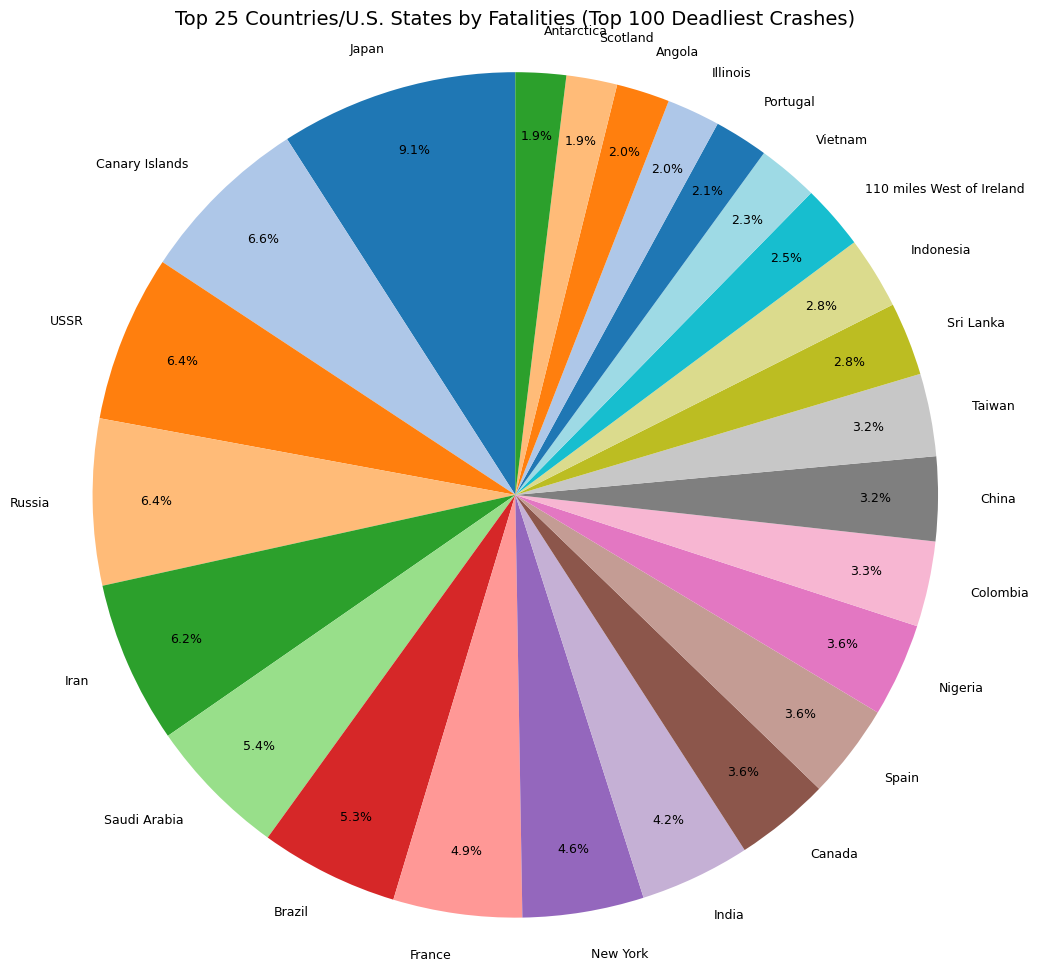

In [16]:
#10. Pie chart: top 25 fatalities per Country/U.S. State
top_25 = (top_100.groupby('State/Country')['Fatalities']
          .sum()
          .sort_values(ascending=False)
          .head(25))

colors = sns.color_palette('tab20', 25)
plt.figure(figsize=(12, 12))
plt.pie(top_25, labels=top_25.index, autopct='%1.1f%%', startangle=90,
        colors=colors, pctdistance=0.85, textprops={'fontsize': 9})
plt.title('Top 25 Countries/U.S. States by Fatalities (Top 100 Deadliest Crashes)', fontsize=14)
plt.axis('equal')
plt.show()